# K‑Means Clustering of Spanish Startups
Unsupervised ML applied to firm‑level financial characteristics from SABI.

The analysis here uses `Sabi_subsample.dta`. This contains a random subsample of firms from *Sistema de Análisis de Balances Ibéricos* (SABI) (equivalent to Orbis/Amadeus for the Iberian peninsula).

The goal of this exercise is to implement **K-means clustering**, an *unsupervised machine learning* algorithm that groups observations based on shared characteristics or features. The algorithm partitions observations into a set number of `K` clusters by minimizing the distance (usually the Euclidean distance) between each point and the centroid of its assigned cluster. 

Note that the K-means algorithm is sensitive to the initial choice of cluster centers. Thus, one can run the algorithm multiple times with different initial guesses and choose the solution with the smallest objective function value. Most implementations, including that of *scikit-learn*, allow for this via the `n_init` parameter.

The scale of the data can also have an impact on the clustering results. Thus, it is often recommended to standardize the data before applying the K-means algorithm. 

In this exercise, we follow <span style="color:blue">De Haas et al. (2022)</span> and use k-means to uncover natural groupings within startups, based on financial and structural characteristics such as *leverage*, *liquidity*, *tangibility*, and *size (in terms of total assets and number of employees)*. 

Reference:
- De Haas, Ralph, Vincent Sterk and Neeltje Van Horen. (2022). "Start-up types and macroeconomic performance in Europe," Bank of England working papers 986, Bank of England.

## Table of Contents

1. [Load packages](#1.-Load-packages)
2. [Load and clean data](#2.-Load-and-clean-data)
3. [Exploratory data overview](#3.-Exploratory-data-overview)
4. [Determine optimal number of clusters](#4.-Determine-optimal-number-of-clusters) 
5. [K-means clustering](#5.-K-means-clustering)
6. [Cluster profiles](#6.-Cluster-profiles)
7. [Cosine similarity between cluster centers](#7.-Cosine-similarity-between-cluster-centers)
8. [Summary and Conclusion](#8.-Summary-and-Conclusion)

## 1. Load packages

In [296]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler 

# Clustering
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Utilities
import warnings
warnings.filterwarnings("ignore")

## 2. Load and clean data
In this section, we:

1. [Load the SABI subsample](#2.1-Import-data)
2. [Exclude non-standard sectors](#2.2-Exclude-non-standard-sectors)
3. [Construct variables](#2.3-Construct-variables)
4. [Winsorize key financial variables](#2.4-Winsorize-variables)
5. [Standardize features](#2.5-Standardize-features)

### 2.1 Import data

In [299]:
# Load the data
file_path = "/Users/andrealorensy/Desktop/Andrea's Files/CEMFI/Other data/Sabi_subsample.dta"  # Use your file path here
raw_data = pd.read_stata(file_path)

# Display basic information about the dataset
raw_data.head()

,year,firmID,estab_year,Equity,Working_capital,EBITDA,Tangible_FA,NACE_2digit,NACE_code,postal_code,...,LTdebt,Cash,ST_FinInv,Material_cost,Interest_expense,age,STdebt_tot,Total_debt,Liquidity,sector_exclude
0,2001,1000777,1942.0,3866570.02,3838623.340,338573.140,2223964.70,46,4674,48006.0,...,841416.95,299504.529,1066.80,5873993.77,143604.44,59.0,1497653.125,2339070.000,3.005713e+05,NaN
1,2002,1000777,1942.0,3992642.92,2724421.660,431992.329,2225407.42,46,4674,48006.0,...,601012.10,277667.430,1066.80,6423704.75,152133.86,60.0,1359299.250,1960311.375,2.787342e+05,NaN
2,2003,1000777,1942.0,4171305.21,2575553.309,484453.930,2207351.52,46,4674,48006.0,...,360607.26,235875.629,6647.83,6719607.55,140704.08,61.0,1858195.375,2218802.750,2.425235e+05,NaN
3,2004,1000777,1942.0,3278175.42,2403962.340,392795.560,841330.19,46,4674,48006.0,...,620202.42,2815595.099,2554672.05,7056773.78,137269.01,62.0,1644016.125,2264218.500,5.370267e+06,NaN
4,2005,1000777,1942.0,3544598.24,2016220.260,344851.550,562212.00,46,4674,48006.0,...,0.00,721661.200,455823.88,6579242.91,110178.98,63.0,1360340.375,1360340.375,1.177485e+06,NaN


### 2.2 Exclude non-standard sectors

Drop firms in the following sectors: Financial Services, Education, Health and Social Work, Membership Activities. The dummy variable `sector_exclude` tracks these sectors. These are relatively non-standard sectors.

In [301]:
# Drop specific sectors
filtered_data = raw_data[raw_data['sector_exclude'] != 1]

### 2.3 Construct variables

- Create a new data frame that selects only the subset of variables needed for the analysis.
- Construct financial ratios and other variables needed for the analysis.

In [303]:
# Copy data into new data frame
data_reg = filtered_data.copy()

# Basic ratio variables
data_reg['leverage']     = data_reg['Total_debt'] / data_reg['Assets'].replace(0, np.nan)
data_reg['liq_ratio']    = data_reg['Liquidity'] / data_reg['Assets'].replace(0, np.nan)
data_reg['tang_ratio']   = data_reg['Tangible_FA'] / data_reg['Assets'].replace(0, np.nan)

# Sort by firm and year
data_reg = data_reg.sort_values(by=['firmID', 'year']).reset_index(drop=True)

# Log transformations
data_reg['l_Assets']  = np.log(data_reg['Assets'].replace(0, np.nan))

In [304]:
# List all columns (variables)
print(data_reg.columns.tolist())

['year', 'firmID', 'estab_year', 'Equity', 'Working_capital', 'EBITDA', 'Tangible_FA', 'NACE_2digit', 'NACE_code', 'postal_code', 'revenue', 'Fixed_Assets', 'employees', 'Wages', 'Assets', 'Current_liab', 'LTdebt', 'Cash', 'ST_FinInv', 'Material_cost', 'Interest_expense', 'age', 'STdebt_tot', 'Total_debt', 'Liquidity', 'sector_exclude', 'leverage', 'liq_ratio', 'tang_ratio', 'l_Assets']


In [305]:
# Detailed info about data types and non-null counts
print(data_reg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898797 entries, 0 to 898796
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              898797 non-null  int16  
 1   firmID            898797 non-null  int32  
 2   estab_year        898716 non-null  float64
 3   Equity            898778 non-null  float64
 4   Working_capital   890261 non-null  float64
 5   EBITDA            898664 non-null  float64
 6   Tangible_FA       872457 non-null  float64
 7   NACE_2digit       898797 non-null  int8   
 8   NACE_code         898797 non-null  int16  
 9   postal_code       898529 non-null  float64
 10  revenue           898797 non-null  float64
 11  Fixed_Assets      898797 non-null  float64
 12  employees         898797 non-null  int32  
 13  Wages             870714 non-null  float64
 14  Assets            898797 non-null  float64
 15  Current_liab      898667 non-null  float64
 16  LTdebt            89

In [306]:
# Subset of variables for K-means clustering
data_kmm = data_reg[['firmID', 'year', 'NACE_2digit', 'NACE_code', 'age', 'estab_year',
                     'leverage', 'liq_ratio', 'tang_ratio', 'employees','l_Assets']]

data_kmm_clean = data_kmm.dropna(subset=vars_to_treat).copy()

# Keep startups only
data_kmm_clean = data_kmm_clean[data_kmm_clean['year'] == data_kmm_clean['estab_year']]

### 2.4 Winsorize variables

In [308]:
# Define list of variables to be winsorized
vars_to_treat = ['leverage', 'liq_ratio', 'tang_ratio', 'employees', 'l_Assets']

# Winsorize variables to be used for regressions
def winsorize_series_inplace(s, lower_percentile=0.01, upper_percentile=0.99):
    lower = s.quantile(lower_percentile)
    upper = s.quantile(upper_percentile)
    
    # Replace values less than lower with lower, and values greater than upper with upper
    # This "clips" the series between the lower and upper bounds
    return s.clip(lower, upper)

for var in vars_to_treat:
    # Replace the original column in data_reg with its winsorized version
    data_kmm_clean[var] = winsorize_series_inplace(data_kmm_clean[var])

### 2.5 Standardize features

In [310]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_kmm_clean[vars_to_treat])
X_scaled_df = pd.DataFrame(X_scaled, columns=vars_to_treat, index=data_kmm_clean.index)

## 3. Exploratory data overview

#### Descriptive statistics on non-standardized variables

In [313]:
data_kmm_clean[vars_to_treat].describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
leverage,18489.0,0.1740,0.2728,0.0000,0.0000,0.0000,0.2893,1.0389
liq_ratio,18489.0,0.2428,0.2375,0.0009,0.0568,0.1635,0.3584,0.9680
tang_ratio,18489.0,0.2371,0.2469,0.0000,0.0275,0.1463,0.3884,0.9083
employees,18489.0,3.2513,5.5968,0.0000,0.0000,2.0000,4.0000,39.0000
l_Assets,18489.0,11.5203,1.3614,8.3653,10.6293,11.4640,12.3390,15.6997


#### Descriptive statistics on variables (to check if standardization was done correctly)

Note: Since these are standardized variables, it should not be surprising to see negative values on financial ratios and number of employees!

In [315]:
X_scaled_df.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
leverage,18489.0,-0.0,1.0,-0.6378,-0.6378,-0.6378,0.4225,3.1704
liq_ratio,18489.0,-0.0,1.0,-1.0182,-0.7832,-0.3337,0.4868,3.0530
tang_ratio,18489.0,0.0,1.0,-0.9604,-0.8492,-0.3679,0.6125,2.7181
employees,18489.0,0.0,1.0,-0.5809,-0.5809,-0.2236,0.1338,6.3875
l_Assets,18489.0,0.0,1.0,-2.3175,-0.6545,-0.0414,0.6014,3.0699


## 4. Determine optimal number of clusters

Here, we use the **Elbow method** and **Silhouette method** to determine the optimum number of clusters, and use alternative metrics as additional diagnostics.

1. [Elbow Method](#4.1-Elbow-Method)
2. [Silhouette Method](#4.2-Silhouette-Method)
3. [Additional diagnostics](#4.3-Additional-diagnostics)
4. [Summary](#4.4-Summary)

### 4.1 Elbow Method

**Goal**: To choose the optimal number of clusters (`k`) in K-Means by looking at how the model’s performance improves with more clusters.

- Inertia = sum of squared distances between each point and its nearest cluster center.
- As you increase `k`, inertia decreases (clusters fit the data better).

The idea is that, initially, adding clusters dramatically reduces inertia. But at some point, adding more clusters yields diminishing returns. The “elbow” in the plot (a sharp bend) marks the ideal balance between:
- Model simplicity (fewer clusters)
- Fit (lower inertia)

#### Implementing the elbow method

Note: inertia is the sum of squared distances to the nearest cluster center

In [319]:
inertias = [KMeans(n_clusters=n, n_init=10, random_state=42).fit(X_scaled_df).inertia_ for n in range(1, 11)]

#### Plotting the inertia

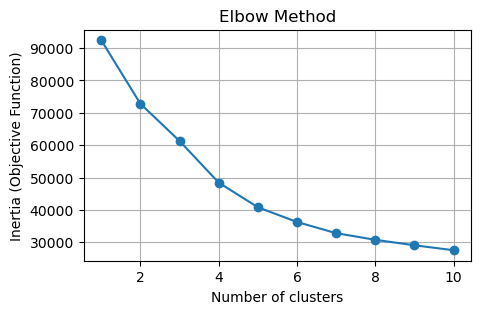

In [321]:
# Plot the inertia
fig, ax = plt.subplots(figsize=(5, 3))  # Set the figure size here
ax.plot(range(1, 11), inertias, marker='o')
ax.set(xlabel='Number of clusters', ylabel='Inertia (Objective Function)')
ax.set_title('Elbow Method')
ax.grid(True)

plt.show()

<br>

### 4.2 Silhouette Method

**Goal**: Evaluate how well your data is clustered — do the clusters make sense?

**Silhouette Score** for each point:

$$
s = \frac{b - a}{\max(a, b)}
$$

- `a` = average distance to points within the same cluster
- `b` = average distance to points in the nearest neighboring cluster

A high average silhouette score suggests that clusters are tight and well-separated. The idea is to compute the average silhouette score for each value of `k` and choose the one with the highest score.

#### Compute the silhouette scores

In [324]:
# Compute the silhouette scores
sil_scores = []
for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, n_init=10, random_state=42).fit(X_scaled_df)
    sil_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

#### Plotting the silhouette score

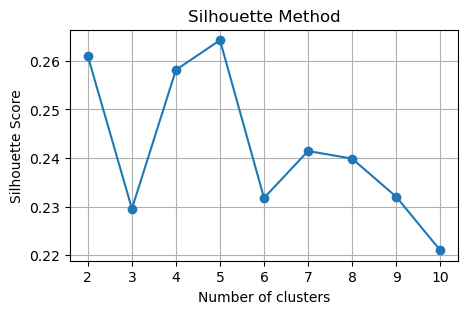

In [326]:
# Plot silhouette score
plt.figure(figsize=(5, 3))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.grid(True)
plt.show()

### 4.3 Additional diagnostics

1. Calinski–Harabasz Index (CH Index)
    - Measures how well-separated and compact the clusters are.
    - Formula:
        $$ CH(k) = \frac{\text{Between-cluster variance}}{\text{Within-cluster variance}} \cdot \frac{n-k}{k-1}$$
    - where $n$ = number of samples; $k$ = number of clusters
    - Higher CH score = better clustering
    - Points in each cluster are close to each other (low within-cluster dispersion)
    - Clusters are far apart (high between-cluster dispersion)
<br> <br>

2. Davies–Bouldin Index (DB Index)
    - Measures similarity between clusters — lower is better.
    - Formula:
        $$ \text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \ne i} \left( \frac{S_i + S_j}{M_{ij}} \right)$$
    - where:
      - $S_i = \frac{1}{|C_i|} \sum_{x \in C_i} \|x - c_i\|$ is the average distance between each point in cluster $i$ and the centroid of cluster $i$ (intra-cluster scatter)
      - $M_{ij} = \|c_i - c_j\|$ is the distance between cluster centroids $i$ and $j$
    - Lower values mean:
        - Clusters are compact
        - Clusters are well-separated from each other

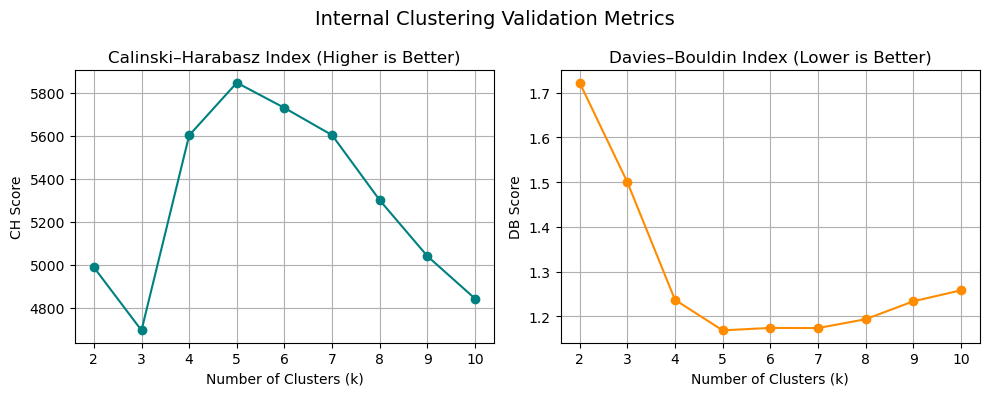

In [328]:
# Range of cluster counts to test
k_range = range(2, 11)

# Store scores
ch_scores = []
db_scores = []

# Run KMeans for each k and compute metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled_df)
    labels = kmeans.labels_
    
    ch = calinski_harabasz_score(X_scaled_df, labels)
    db = davies_bouldin_score(X_scaled_df, labels)
    
    ch_scores.append(ch)
    db_scores.append(db)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Calinski–Harabasz
ax[0].plot(k_range, ch_scores, marker='o', color='teal')
ax[0].set_title("Calinski–Harabasz Index (Higher is Better)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("CH Score")
ax[0].grid(True)

# Davies–Bouldin
ax[1].plot(k_range, db_scores, marker='o', color='darkorange')
ax[1].set_title("Davies–Bouldin Index (Lower is Better)")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("DB Score")
ax[1].grid(True)

plt.suptitle("Internal Clustering Validation Metrics", fontsize=14)
plt.tight_layout()
plt.show()


#### 4.4 Summary

- Elbow method seems to suggest that $k = 4$ clusters is likely the elbow point — the place where adding more clusters gives diminishing returns.
- 5 or 6 clusters might technically improve the fit (lower inertia), but not meaningfully enough to justify the extra complexity.
<!-- With $k = 4$ clusters, each cluster has a clear interpretation.-->

- Silhouette method suggests that $k = 5$ clusters is optimal.
<!-- Yet, for $k = 5$ clusters (analysis not shown here), it is hard to pin down an exact description of one of the clusters (somewhat large, but not as big as the "large" startups in terms of `l_Assets` and `employees`).-->

- Other clustering evaluation metrics suggest that $k = 5$ clusters is optimal.
- <span style="color:red">
Thus, we will use $k = 5$ clusters in the K-means clustering analysis.
</span>

## 5. K-means clustering

#### Implement the k-means algorithm

In [332]:
# Define the number of clusters
n_clusters=5

# Implement the k-means algorithm
kmeans5 = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X_scaled_df)

#### Print cluster centers

In [334]:
kmeans5.cluster_centers_

array([[-0.37835265, -0.44411951,  1.29799372, -0.18055889, -0.2537503 ],
       [-0.39764862, -0.40797269, -0.57017869, -0.11590265,  0.15915217],
       [ 1.82291332, -0.41759089,  0.63259461, -0.13670816,  0.37389782],
       [-0.44167573,  1.53172814, -0.54013521, -0.2265659 , -0.649356  ],
       [-0.0401403 , -0.15963046, -0.18706552,  4.27298981,  1.5154471 ]])

## 6. Cluster profiles

1. [Descriptive statistics on the clusters](#6.1-Descriptive-statistics-on-the-clusters)
2. [Distribution of variables across clusters](#6.2-Distribution-of-variables-across-clusters)
3. [Multivariate visualization of clusters](#6.3-Multivariate-visualization-of-clusters)
4. [Discussion](#6.4-Discussion)

### 6.1 Descriptive statistics on the clusters

#### Unscale the data for analysis of clusters

In [338]:
X_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_scaled_df[vars_to_treat]),
    columns=vars_to_treat,
    index=X_scaled_df.index
)

#### Add cluster labels to original data

In [340]:
# Add cluster labels to original data
data_kmm_clean['cluster'] = kmeans5.labels_
X_unscaled['cluster'] = kmeans5.labels_

#### Mean values of each variable by cluster

In [342]:
cluster_profiles = data_kmm_clean.groupby('cluster')[vars_to_treat].mean().round(2)
print('------------ Mean ------------')
print(cluster_profiles)

------------ Mean ------------
         leverage  liq_ratio  tang_ratio  employees  l_Assets
cluster                                                      
0            0.07       0.14        0.56       2.24     11.18
1            0.07       0.15        0.10       2.60     11.74
2            0.67       0.14        0.39       2.49     12.03
3            0.05       0.61        0.10       1.98     10.64
4            0.16       0.20        0.19      27.17     13.58


#### Number of Observations and Share per Cluster

In [344]:
# Count observations per cluster
cluster_counts = data_kmm_clean['cluster'].value_counts().sort_index()

# Compute share
cluster_share = cluster_counts / cluster_counts.sum()

# Combine into a DataFrame
cluster_summary = pd.DataFrame({
    'count': cluster_counts,
    'share': cluster_share
})

# Format share as percentage (4 decimals)
cluster_summary['share'] = cluster_summary['share'].round(4)

# Display
print('\n------------ Number of Observations and Share per Cluster ------------')
print(cluster_summary)


------------ Number of Observations and Share per Cluster ------------
         count   share
cluster               
0         3352  0.1813
1         7354  0.3978
2         3255  0.1761
3         3877  0.2097
4          651  0.0352


#### Cluster name map

In [391]:
# Rename cluster labels after observing summary stats on clusters
cluster_name_map = {
    0: 'K-intensive',
    1: 'Basic',
    2: 'High leverage',
    3: 'Cash-intensive',
    4: 'Large',
}

data_kmm_clean['cluster_named'] = data_kmm_clean['cluster'].map(cluster_name_map)
X_unscaled['cluster_named'] = X_unscaled['cluster'].map(cluster_name_map)

### 6.2 Distribution of variables across clusters

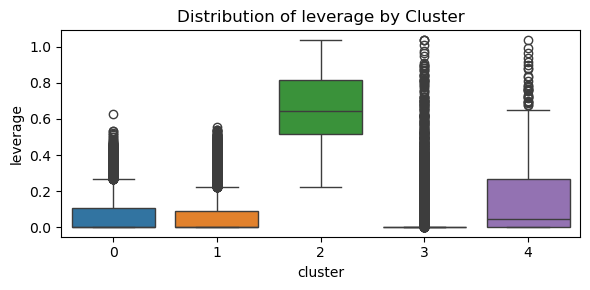

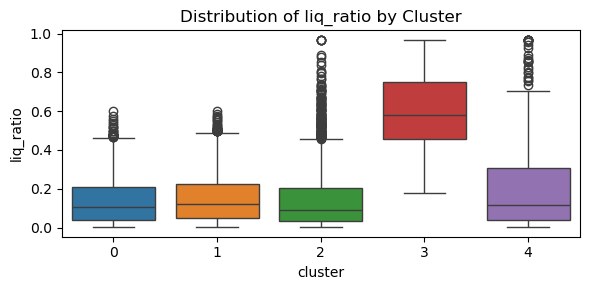

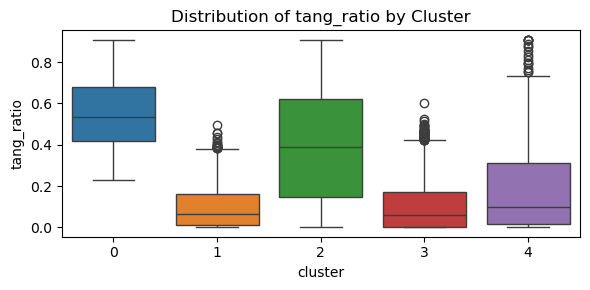

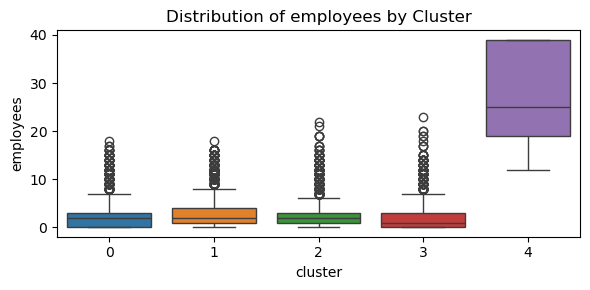

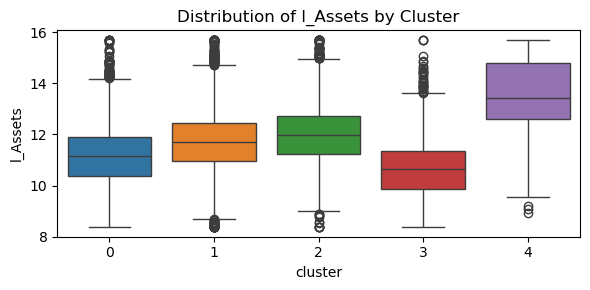

In [384]:
# Plot distribution of variables across clusters
for var in vars_to_treat:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=data_kmm_clean, x='cluster', y=var, hue='cluster', palette='tab10', legend=False)
    plt.title(f'Distribution of {var} by Cluster')
    plt.tight_layout()
    plt.show()

### 6.3 Multivariate visualization of clusters

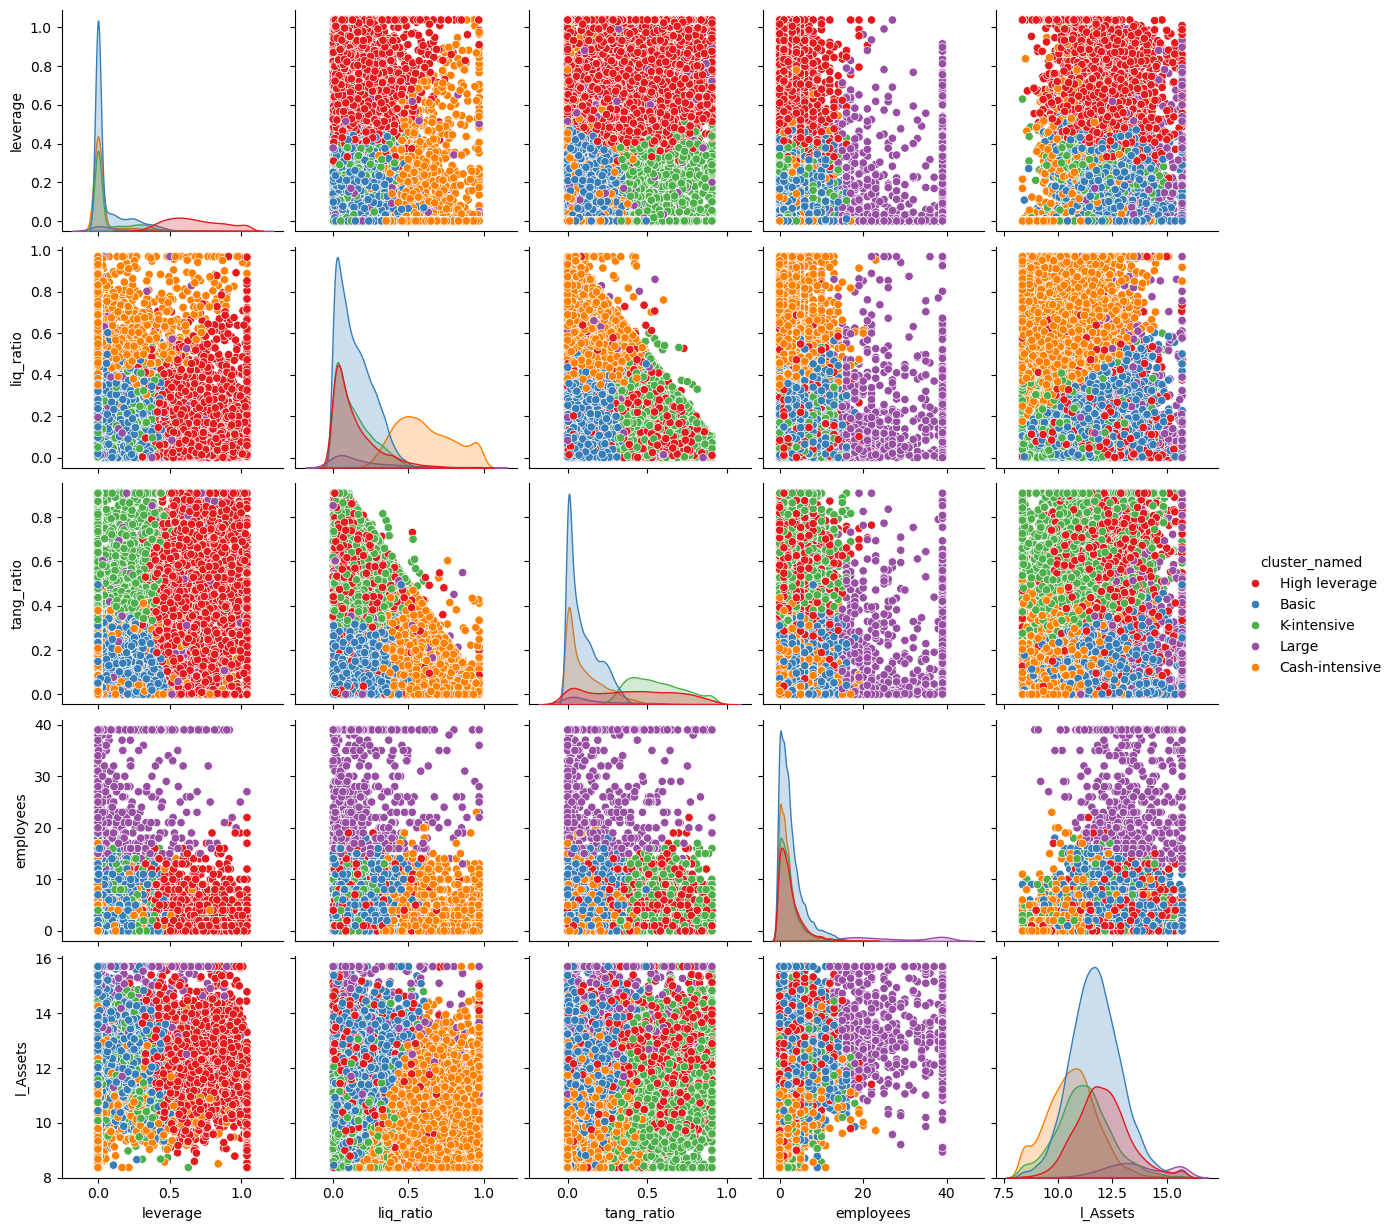

In [386]:
# Pairplots
sns.pairplot(X_unscaled[vars_to_treat + ['cluster_named']], hue='cluster_named', palette='Set1')

### 6.4 Discussion 

The results indicate that the 5 clusters capture distinct firm profiles based on the financial indicators used in the clustering procedure. Each cluster reflects a different combination of size, liquidity, leverage, and asset structure:

- **Cluster 0: Capital-intensive startups**<br>
  This cluster is characterized by a high share of tangible assets. These firms likely operate in capital‑intensive industries (e.g., manufacturing, construction) where physical assets play a central role.

- **Cluster 1: Basic startups**<br>
  This group does not exhibit extreme values in any of the variables. These firms represent a “typical” or “average” profile in the dataset, serving as a baseline against which the other clusters can be compared.

- **Cluster 2: Highly leveraged startups**<br>
  Firms in this cluster exhibit the highest leverage ratios. They rely heavily on debt financing, which may indicate aggressive growth strategies or financial vulnerability depending on profitability and cash flows.

- **Cluster 3: Cash-intensive startups** <br>
  Firms have a high share of liquid assets in total assets. These firms maintain strong liquidity positions, possibly reflecting conservative financial management or limited investment opportunities.

- **Cluster 4: Large startups** <br>
  This group of firms is large in terms of total number of employees and balance sheet size (total assets).

  
Overall, the clustering solution appears economically meaningful: each cluster corresponds to a recognizable firm type, and the distinctions align with standard dimensions of firm heterogeneity such as size, leverage, liquidity, and asset structure.  

## 7. Cosine similarity between cluster centers

**Cosine similarity** measures the angle between two vectors in a multi-dimensional space.
- It tells you how similar the direction of two vectors is.
- It ignores magnitude (length) and focuses purely on orientation.

For two vectors **A** and **B**, the cosine similarity is: 
$$ \text{cosine\_similarity} = \frac{A \cdot B}{||A|| \cdot ||B||} $$
 
- $A \cdot B$ = dot product of vectors
- ||A|| and ||B|| = Euclidean norms

The cosine similarity always belongs to the interval $[−1,+1]$. For example, two proportional vectors have a cosine similarity of +1, two orthogonal vectors have a similarity of 0, and two opposite vectors have a similarity of −1.

#### Compute the cosine similarity

In [394]:
# Cosine similarity between scaled cluster centers
cos_sim_matrix = cosine_similarity(kmeans5.cluster_centers_)

In [396]:
# Create ordered labels based on cluster indices
labels = [cluster_name_map[i] for i in range(n_clusters)]

# Cosine similarity DataFrame with named rows/columns
cos_sim_df = pd.DataFrame(
    cos_sim_matrix,
    index=labels,
    columns=labels
)

print("Cosine Similarity Between Cluster Centers:")
print(cos_sim_df.round(3))

Cosine Similarity Between Cluster Centers:
                K-intensive  Basic  High leverage  Cash-intensive  Large
K-intensive           1.000 -0.354          0.084          -0.381 -0.198
Basic                -0.354  1.000         -0.503          -0.145 -0.018
High leverage         0.084 -0.503          1.000          -0.546 -0.016
Cash-intensive       -0.381 -0.145         -0.546           1.000 -0.252
Large                -0.198 -0.018         -0.016          -0.252  1.000


#### Heatmap

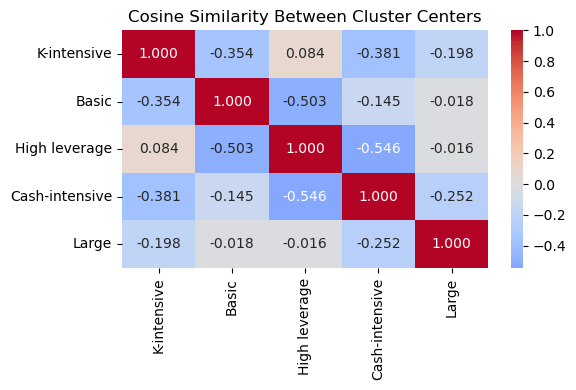

In [401]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cos_sim_df,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".3f"
)
plt.title("Cosine Similarity Between Cluster Centers")
plt.tight_layout()
plt.show()

#### Reading the results:

- Basic vs. High leverage = –0.503 <br>
  These clusters point in strongly opposite directions, reflecting the contrast between neutral firms and highly debt‑financed firms.

- K‑intensive vs. High leverage = 0.084 <br>
  Almost orthogonal; capital‑intensive firms and highly leveraged firms differ along unrelated dimensions.

- K‑intensive vs. Cash‑intensive = –0.381 <br>
  Moderate dissimilarity; asset‑heavy firms contrast with liquidity‑rich, asset‑light firms.

- Cash‑intensive vs. High leverage = –0.546 <br>
  Strongest negative relationship; cash‑rich firms are the opposite of debt‑heavy firms.

- Large cluster vs. all others ≈ near zero  <br>
  The Large cluster is mostly orthogonal to the rest, indicating that firm size is an independent dimension not strongly aligned with leverage, liquidity, or tangibility.

Overall, the cosine similarity results confirm that the clusters are well-separated and capture meaningfully different characteristics of startups.

## 8. Summary and Conclusion

To summarize, the analysis uncovers 5 types of startups in Spain:

- **K-intensive**: firms with a high tangible asset share and relatively higher leverage, indicating capital‑heavy business models
- **Basic**: firms that do not stand out along any financial dimension; they represent the “average” startup profile.
- **High leverage**: firms with substantially higher debt ratios, distinguishing them by their reliance on external financing.
- **Cash-intensive**: high share of liquid assets in total assets, suggesting conservative financial management or low initial investment needs.
- **Large**: large in terms of total number of employees and balance sheet size (total assets)

In terms of prevalence, **Basic** startups are the most common, representing roughly **40%** of the sample. They are followed by **Cash‑intensive (20.9%)**, **K‑intensive (18.1%)**, and **High leverage (17.6%)** startups. The **Large** cluster is the smallest group, reflecting the relative rarity of firms that begin operations with substantial scale.

Note that in this analysis using a subsample of Spanish firms (firm-level data), the level of leverage in **high leverage** firms do not seem to go beyond a ratio of 1, while in De Haas et al. (2022), it does. **High leverage** firms in De Haas et al. (2022) clearly capture firms that are very leveraged and at risk. This may be due to differences in the data used for analysis, for example:
- *CompNet* uses *micro-aggregated* data, not *firm-level* data.
- *SABI* does not have complete coverage of the self-employed firms (i.e. zero-employment firms).

Overall, the segmentation shows that early‑stage Spanish startups differ not only in size but also in their underlying financial structure, which affects their risk profile, financing needs, and growth potential. Most firms start in a balanced, low‑risk position, but a meaningful share adopt more distinctive strategies—either holding large cash buffers or committing heavily to fixed assets. The **High leverage** group, while not extreme, still represents firms that may be more exposed if credit conditions tighten. Meanwhile, the **Large** startups, though rare, enter the market with more resources and may scale more quickly simply because they start from a different baseline. These differences matter for lenders, investors, and support institutions because they point to different risk exposures and different timelines for when firms might need external financing.